# Meta Model - Ensembling Five Models using Stacking


## Imports

In [2]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_predict, RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
RANDOM_STATE = 42
target_col = 'Depression'

## Load Base Models

In [4]:
dt_model = joblib.load("/workspaces/CS_Group07_StudentDepressionDetection/notebooks/dunith_decision_tree/decision_tree_model.joblib")
rf_model = joblib.load("/workspaces/CS_Group07_StudentDepressionDetection/notebooks/fc211009_Themiya_random_forrest/random_forest_student_depression.joblib")
svm_model = joblib.load("/workspaces/CS_Group07_StudentDepressionDetection/notebooks/fc211011_kaveesha_svm_model/best_svm_model.joblib")
gb_model = joblib.load("/workspaces/CS_Group07_StudentDepressionDetection/notebooks/menura-gradient_boosting_classifier/gbc_model.joblib")
lr_model = joblib.load("/workspaces/CS_Group07_StudentDepressionDetection/notebooks/Rushani_Logistic_Regression/final_logistic_model.joblib")

models = {
    'DecisionTree': dt_model,
    'RandomForest': rf_model,
    'SVM': svm_model,
    'GradientBoosting': gb_model,
    'LogisticRegression': lr_model
}

## Load Dataset 

In [5]:
df = pd.read_csv("/workspaces/CS_Group07_StudentDepressionDetection/notebooks/menura-gradient_boosting_classifier/preprocessed_student_depression(GBC-model).csv")  
X = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
print("Data loaded:")
print("X shape:", X.shape)
print("\ny distribution:\n", y.value_counts())

Data loaded:
X shape: (27867, 12)

y distribution:
 Depression
1    16307
0    11560
Name: count, dtype: int64


## Split Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [8]:
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (22293, 12)  Test shape: (5574, 12)


## Preprocessing

### Identify feature types

In [9]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols, "\n")

Numeric cols: ['Age', 'Academic_Pressure', 'CGPA', 'Study_Satisfaction', 'Study_Hours', 'Financial_Stress']
Categorical cols: ['Gender', 'Sleep_Duration', 'Dietary_Habits', 'Degree', 'Suicidal_Thoughts', 'Mental_Illness_History'] 



### Different Preprocessors for Base Models

In [10]:
preprocess_1 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

preprocess_2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

### Pipelines

In [11]:
# Decision Tree 
dt_pipeline = Pipeline([
    ("preprocess", preprocess_1),
    ("model", DecisionTreeClassifier(
        max_depth=9,
        min_samples_leaf=3,
        random_state=42
    ))
])

# Random Forest 
rf_pipeline = Pipeline([
    ("preprocess", preprocess_2),
    ("model", RandomForestClassifier(
        n_estimators=193,
        max_depth=26,
        min_samples_leaf=2,
        min_samples_split=11,
        bootstrap=False,
        max_features="sqrt",
        random_state=42
    ))
])

# Gradient Boosting 
gbc_pipeline = Pipeline([
    ("preprocess", preprocess_2),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        subsample=0.8,
        max_features="sqrt",
        min_samples_split=5,
        random_state=42
    ))
])

# SVM pipeline 
svm_pipeline = ImbPipeline([
    ("preprocess", preprocess_2),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        C=0.1,
        gamma="auto",
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

# Logistic Regression 
logreg_pipeline = ImbPipeline([
    ("preprocess", preprocess_2),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        C=0.1,
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

In [12]:
# Base Estimators
base_estimators = [
    ("dt", dt_pipeline),
    ("rf", rf_pipeline),
    ("gbc", gbc_pipeline),
    ("svm", svm_pipeline),
    ("logreg", logreg_pipeline),
]

## Meta Model 1

### Estimator

In [16]:
meta_model_est = LogisticRegression(
    max_iter=5000,
    solver="liblinear",
    random_state=42
)

### Stacking Classifier

In [17]:
meta_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model_est,
    stack_method="predict_proba",  
    passthrough=False,            
    cv=5,                          
    n_jobs=1
)

### Model Training

In [18]:
meta_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('dt',
                                Pipeline(steps=[('preprocess',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  'passthrough',
                                                                                  ['Age',
                                                                                   'Academic_Pressure',
                                                                                   'CGPA',
                                                                                   'Study_Satisfaction',
                                                                                   'Study_Hours',
                                                                                   'Financial_Stress']),
                                                                                 ('cat',
                                                                                  OneHotEncoder(handle_unknown='ignore'),
                                                                                  ['Gender',
                                                                                   'Sleep_Duration',
                                                                                   'Dietary_Habits',
                                                                                   'Degree',
                                                                                   'Suicidal_Thoughts',
                                                                                   'Mental_Illness_...
                                                                                   'Sleep_Duration',
                                                                                   'Dietary_Habits',
                                                                                   'Degree',
                                                                                   'Suicidal_Thoughts',
                                                                                   'Mental_Illness_History'])])),
                                                ('smote',
                                                 SMOTE(random_state=42)),
                                                ('model',
                                                 LogisticRegression(C=0.1,
                                                                    max_iter=5000,
                                                                    penalty='l1',
                                                                    random_state=42,
                                                                    solver='liblinear'))]))],
                   final_estimator=LogisticRegression(max_iter=5000,
                                                      random_state=42,
                                                      solver='liblinear'),
                   n_jobs=1, stack_method='predict_proba')

### Evaluation

In [19]:
y_pred = meta_model.predict(X_test)
y_prob = meta_model.predict_proba(X_test)[:, 1]


print("=========== META-MODEL RESULTS ===========")
print("Train Accuracy:", meta_model.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print(f"ROC-AUC   : ",roc_auc_score(y_test, y_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

=========== META-MODEL RESULTS ===========
Train Accuracy: 0.8677163235096218
Test Accuracy : 0.8457122353785432
ROC-AUC   :  0.9218159619313517
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      2312
           1       0.87      0.87      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574



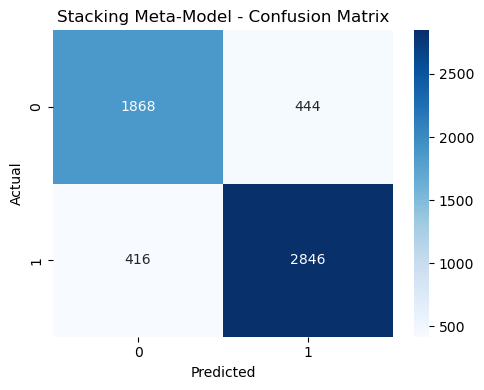

In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Meta-Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

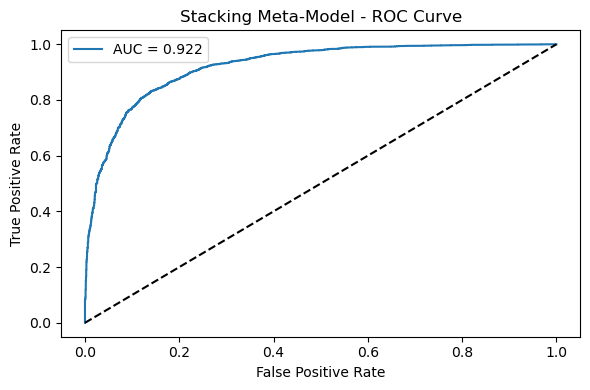

In [21]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Stacking Meta-Model - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## Meta Model 2

### Estimator

In [22]:
base_estimators_xgb = [
    ('dt', dt_model),
    ('rf', rf_model),
    ('svm', svm_model),
    ('gbc', gb_model),
    ('lr', lr_model)
]


In [23]:
meta_model_est_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)

### Stacking Classifier

In [24]:
meta_model_xgb = StackingClassifier(
    estimators=base_estimators_xgb,
    final_estimator=meta_model_est_xgb,
    stack_method='predict_proba',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42),
    n_jobs=1,
    passthrough=False
)

### Model Training

In [25]:
meta_model_xgb.fit(X_train, y_train)

StackingClassifier(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=42),
                   estimators=[('dt',
                                Pipeline(steps=[('preprocess',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  'passthrough',
                                                                                  ['Age',
                                                                                   'Academic_Pressure',
                                                                                   'CGPA',
                                                                                   'Study_Satisfaction',
                                                                                   'Study_Hours',
                                                                                   'Financial_Stress']),
                                                                                 ('cat',
                                                                                  OneHotEncoder(handle_unknown='ignore'),
                                                                                  ['Gender',
                                                                                   'Sleep_Duration',...
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.05,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=4, max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=300, n_jobs=None,
                                                 num_parallel_tree=None, ...),
                   n_jobs=1, stack_method='predict_proba')

### Evaluation

In [26]:
y_pred = meta_model_xgb.predict(X_test)
y_proba = meta_model_xgb.predict_proba(X_test)[:, 1]

print("========== XGBOOST META MODEL RESULTS ==========")
print("Train Accuracy:", meta_model_xgb.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC       :", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

========== XGBOOST META MODEL RESULTS ==========
Train Accuracy: 0.8481137576817835
Test Accuracy : 0.8466092572658773
ROC-AUC       : 0.9210176717745922

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      2312
           1       0.86      0.88      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574



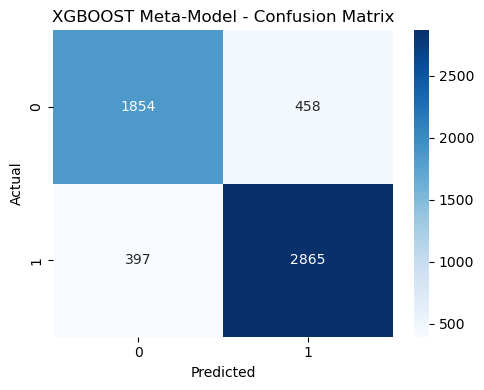

In [27]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBOOST Meta-Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

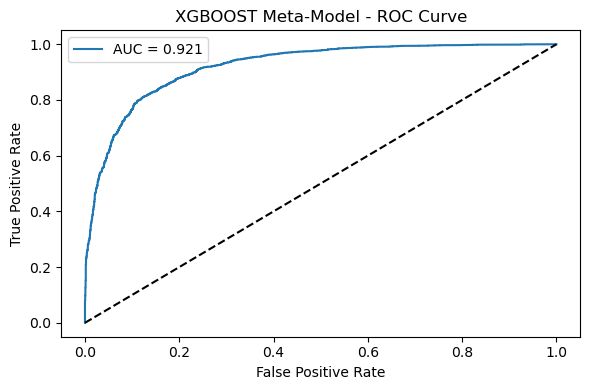

In [28]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.title("XGBOOST Meta-Model - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning forXGB

### OOF

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

meta_train = []
meta_test = []

for name, model in models.items():
    print(f"Generating OOF predictions for: {name}")

    # OOF predictions for training
    oof_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=1
    )[:, 1]   

    # Predictions for test set
    test_pred = model.predict_proba(X_test)[:, 1]

    meta_train.append(oof_pred)
    meta_test.append(test_pred)


meta_train = np.column_stack(meta_train)
meta_test = np.column_stack(meta_test)

print("Meta-train shape:", meta_train.shape)
print("Meta-test shape:", meta_test.shape)


Generating OOF predictions for: DecisionTree
Generating OOF predictions for: RandomForest
Generating OOF predictions for: SVM
Generating OOF predictions for: GradientBoosting
Generating OOF predictions for: LogisticRegression
Meta-train shape: (22293, 5)
Meta-test shape: (5574, 5)


### Parameters

In [14]:
meta_model_est_xgb_ht = XGBClassifier(
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)

In [15]:
param_distributions = {
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "min_child_weight": [1, 3, 5, 7],
    "n_estimators": [200, 400, 600, 800]
}


In [16]:
meta_model_xgb_ht = RandomizedSearchCV(
    estimator=meta_model_est_xgb_ht,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    n_jobs=1,
    cv=skf,
    verbose=2,
    random_state=42
)

### Model Training

In [17]:
meta_model_xgb_ht.fit(meta_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=400, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=400, subsample=0.8; total time=   1.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=400, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=400, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=400, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=7, n_estimators=200, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_dept

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                           n_estimators=500, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 0.8,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.001, 0.01, 0.05,
                                                          0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 400, 600, 800],
                                        'subsample': [0.6, 0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

### Evaluation

In [18]:
best_xgb = meta_model_xgb_ht.best_estimator_
print("Best Parameters:", meta_model_xgb_ht.best_params_)

y_pred = best_xgb.predict(meta_test)
y_prob = best_xgb.predict_proba(meta_test)[:, 1]

print("\n========== XGBOOST META-MODEL RESULTS ==========")
print("Train Accuracy:", accuracy_score(y_train, best_xgb.predict(meta_train)))
print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC      :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Best Parameters: {'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.001, 'gamma': 0, 'colsample_bytree': 0.5}

========== XGBOOST META-MODEL RESULTS ==========
Train Accuracy: 0.8484726147221101
Test Accuracy : 0.852529601722282
ROC-AUC      : 0.9285487547707798

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      2312
           1       0.84      0.92      0.88      3262

    accuracy                           0.85      5574
   macro avg       0.86      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574



## Save Model

In [19]:
joblib.dump(best_xgb, "best_meta_model.joblib")

['best_meta_model.joblib']

In [3]:
import sklearn

print("sklearn:", sklearn.__version__)


sklearn: 1.5.1
